In [ ]:
# --- 路径修复：notebook 在 Base/ 下，数据在 Data/ 下 ---
import os as _os, sys as _sys
if _os.path.basename(_os.getcwd()) == 'Base':
    _os.chdir('..')
if 'Base' not in _sys.path:
    _sys.path.insert(0, 'Base')

def _find(path):
    """自动检测 Data/ 子目录前缀。"""
    if _os.path.exists(path):
        return path
    alt = _os.path.join('Data', path)
    if _os.path.exists(alt):
        return alt
    return path


In [1]:
import numpy as np
import math
#import fits
import astropy.io.fits as afits
import matplotlib.pyplot as plt
plt.rcParams.update({'axes.labelsize': 'x-large'})
from scipy.interpolate import splev, splrep
import scipy
from scipy import signal

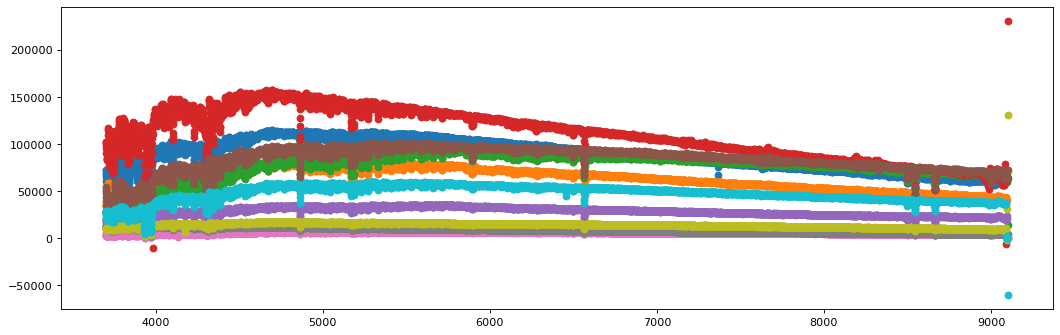

In [2]:
path=_find('downfit/downfitunzip') + '/'
star_hdus = afits.open(path+'alldrnoduplicate.fits') 
star = star_hdus[1].data
star_hdus.close()
nstar_hdus = afits.open(path+'alldrnrich.fits') 
nstar = nstar_hdus[1].data
#nstar_hdus.close()
c=3*10**5  #speed of light

fig=plt.figure(num=None, figsize=(16,5), dpi=80, facecolor='w', edgecolor='k') 
for i in range(10):
    ss_hdus = afits.open(path+'spec-'+str(star['lmjd'][i])+'-'+str(star['planid'][i])+'_sp'+str(star['spid'][i]).zfill(2)+'-'+str(star['fiberid'][i]).zfill(3)+'.fits')
    ss=ss_hdus[0].data
    header=ss_hdus[0].header
    ss_hdus.close()
    #print header['VACUUM'],header['CRVAL1'],header['HELIO']
    #print star['obsid'][i],star['rv'][i]
    dss=ss[2]*(star['rv'][i])/c 
    ssnew=ss[2]-dss
    #print len(ssnew),max(ssnew),min(ssnew)
    spl=splrep(ssnew,ss[0],k=3)
    flxc=splev(ss[2],spl,der=0)    #move to the same pixel space.
    #plt.scatter(ssnew,ss[0])
    plt.scatter(ss[2],flxc)
#plt.xlim([6540, 6590])
plt.show()

In [3]:
ss3890 = range(3800, 9000, 1)
def load_all(NUM):
    datacube=[]
    for i in range(NUM):
        ss_hdus = afits.open(path+'spec-'+str(star['lmjd'][i])+'-'+str(star['planid'][i])+'_sp'+str(star['spid'][i]).zfill(2)+'-'+str(star['fiberid'][i]).zfill(3)+'.fits')
        ss=ss_hdus[0].data
        header=ss_hdus[0].header
        ss_hdus.close()
        #print header['VACUUM'],header['CRVAL1'],header['HELIO']
        #print star['obsid'][i],star['rv'][i]
        dss=ss[2]*(star['rv'][i])/c 
        ssnew=ss[2]-dss
        #print len(ssnew),max(ssnew),min(ssnew)
        spl=splrep(ssnew,ss[0],k=3)
        #flxc=splev(ss[2],spl,der=0)    #move to the same pixel space.
        flxc=splev(ss3890,spl,der=0)    #move to the same pixel space.
        datacube.append(flxc)
    return(ss3890,datacube)

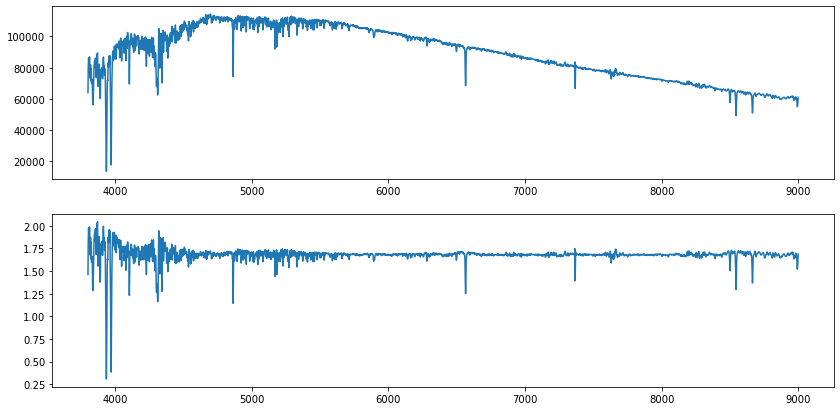

In [4]:
freqs, fluxes = load_all(10)

def smooth_rescale_array(A, n_smooth, n_rescale, deg=3, gass_kernel=True):
    '''
    smooth an array (using 2*n_smooth+1 neighbors) and rescale it to 1 (using 2*n_rescale neighbors)
    '''
#A = np.linspace(0, 6, 300)
#sinA = np.sin(A) + np.random.uniform(0,1, 300) + 1
    # smooth B
    if n_smooth > 1:
        B = signal.savgol_filter(A,2*n_smooth+1,deg)
    else:
        B = A
    # rescale B
    Bmeans = []
    if gass_kernel:
        kernel = np.array(np.exp(- np.linspace(-2, 2, 2*n_rescale+1)**2 / 2))
    for i in range(len(B)):
        i1 = max(0, i-n_rescale); i1=min(i1, len(A)-2*n_rescale-1); i2 = min(i1+2*n_rescale+1, len(A))
        if gass_kernel:
            #print(B[i1:i2].shape, kernel.shape)
            Bmeans.append( (B[i1:i2]*kernel).mean())
            
        else:
            Bmeans.append( B[i1:i2].mean())
    Bmeans = np.array(Bmeans)
    return B / Bmeans

flux = fluxes[0]


fig, axs = plt.subplots(2,1, figsize=(14,7))
axs[0].plot(freqs, flux)
axs[1].plot(freqs, smooth_rescale_array(flux, 0, 100, 3, gass_kernel=True))

In [5]:
from sklearn import cluster, decomposition, covariance, mixture, neighbors

# 1. build a dataset

##### load and normalize

In [8]:
freqs, Xraw = load_all(500)
X = np.array([smooth_rescale_array(flux, 0, 100, 3, gass_kernel=True) for flux in Xraw if len(flux) == len(ss3890)])

# 2. Dimension Reduction + Clustering

##### DR to 32 features

In [9]:
pca = decomposition.PCA(32)
Xproj = pca.fit_transform(X)
X_new = pca.inverse_transform(Xproj)

if False:
    for ix in range(10):
        fig, axs = plt.subplots(1,2, figsize=(16,6))
        axs[0].plot(range(len(X[ix])), X[ix])
        axs[1].plot(range(len(X_new[ix])), X_new[ix])

##### Dimension reduction

In [10]:
model = cluster.KMeans(50)

In [11]:
y = model.fit_predict(X_new)

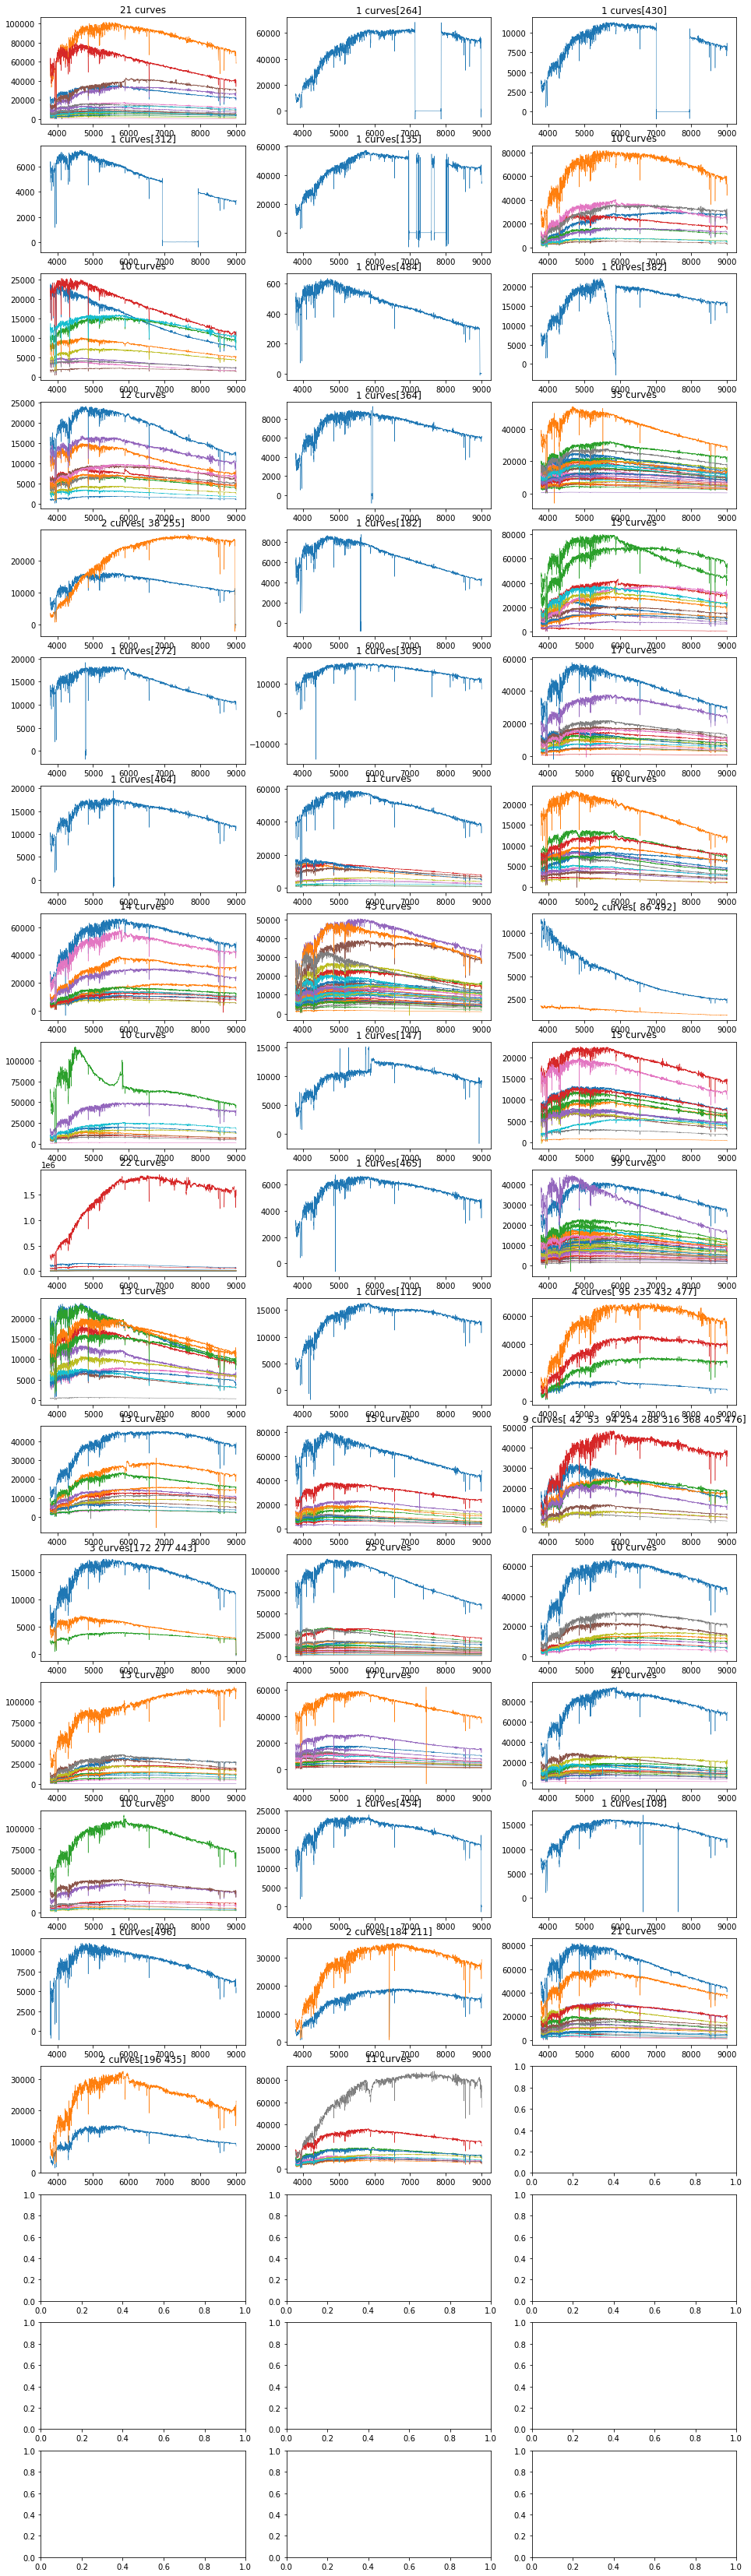

In [14]:
fig, axs = plt.subplots(20,3, figsize=(16,60)); axs= axs.reshape(-1)

for iy in set(list(y)):
    ixs = np.where(y == iy)
    for ix in ixs[0]:
        #axs[iy].plot(freqs[200:1200], X[ix][200:1200], lw=0.5)
        axs[iy].plot(freqs, Xraw[ix], lw=0.5)
        figtitle = str(len(ixs[0]))+' curves'; 
        if len(ixs[0]) < 10: figtitle += str(ixs[0])
        axs[iy].set_title(figtitle)
        #axs[iy].set_ylim(1,2)

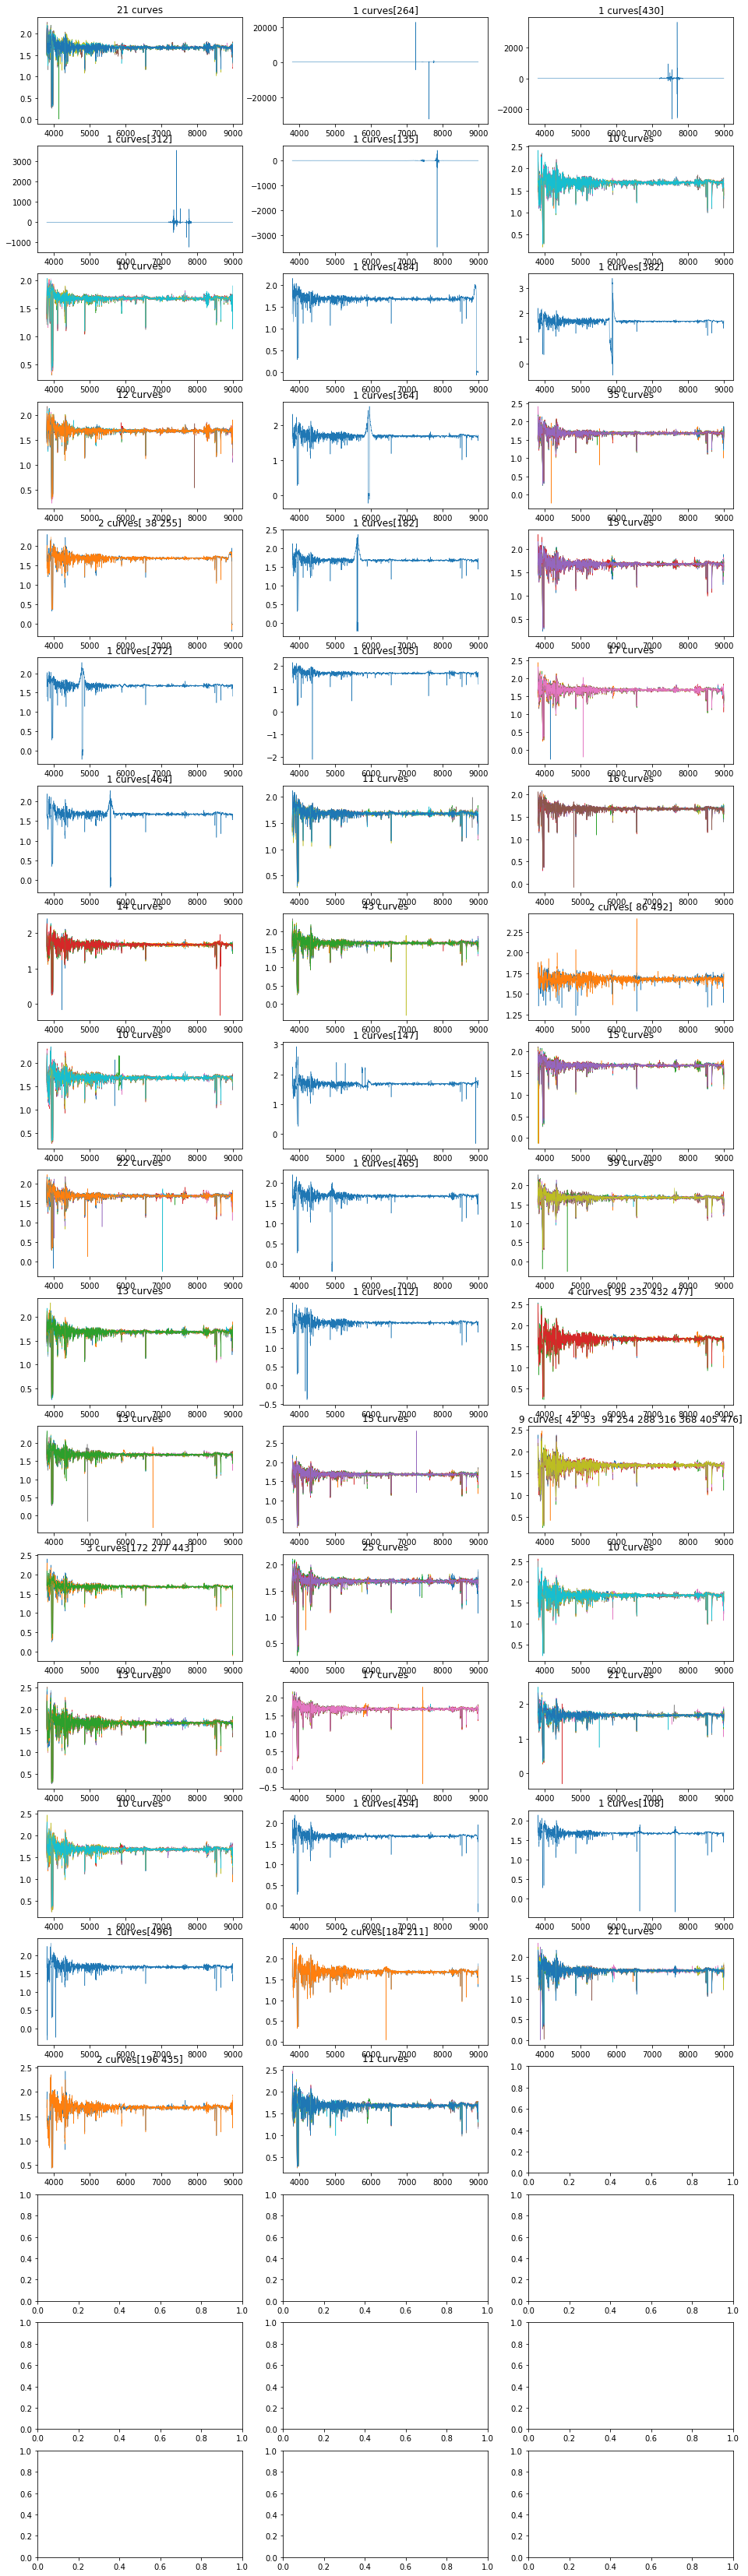

In [15]:
fig, axs = plt.subplots(20,3, figsize=(16,60)); axs= axs.reshape(-1)

for iy in set(list(y)):
    ixs = np.where(y == iy)
    for ix in ixs[0]:
        #axs[iy].plot(freqs[200:1200], X[ix][200:1200], lw=0.5)
        axs[iy].plot(freqs, X[ix], lw=0.5)
        figtitle = str(len(ixs[0]))+' curves'; 
        if len(ixs[0]) < 10: figtitle += str(ixs[0])
        axs[iy].set_title(figtitle)
        #axs[iy].set_ylim(1,2)

# 3. Dimension Reduction + Find NB + Compare

##### DR to 32 numbers

In [17]:
pca = decomposition.PCA(32)
Xproj = pca.fit_transform(X)
X_new = pca.inverse_transform(Xproj)

if False:
    for ix in range(10):
        fig, axs = plt.subplots(1,2, figsize=(16,6))
        axs[0].plot(range(len(X[ix])), X[ix])
        axs[1].plot(range(len(X_new[ix])), X_new[ix])

##### For each sample, find 10 nbs

In [16]:
from sklearn import neighbors

In [18]:
model = neighbors.NearestNeighbors(n_neighbors=10)

In [19]:
model.fit(Xproj)

NearestNeighbors(n_neighbors=10)

In [36]:
distances, nbids = model.kneighbors(Xproj, 10, )

##### concentrate on 4040 - 4260

##### 1. compute distances to 10-nbs

In [70]:
i1, i2 = 4040-3800, 4260-3800
distance_to_mean_of_10nbs = []

for nowid in range(len(X)):
    X0, Xnbs = X[nowid][i1:i2], np.array([xx[i1:i2] for xx in X[nbids[nowid]]])
    Xnb_mean = Xnbs.mean(axis=0)
    distance_to_mean_of_10nbs.append( ( (Xnb_mean - X0)**2).sum())
    if False:
        fig, ax = plt.subplots(figsize=(16,6))
        ax.plot(freqs[i1:i2], X0, lw=3, c='k')
        for xx in Xnbs:
            ax.plot(freqs[i1:i2], xx, lw=0.3, c='r')
distance_to_mean_of_10nbs = np.array(distance_to_mean_of_10nbs)
def plot_curve_with_10nbs(nowid):
    X0, Xnbs = X[nowid][i1:i2], np.array([xx[i1:i2] for xx in X[nbids[nowid]]])
    if True:
        fig, ax = plt.subplots(figsize=(16,6))
        ax.plot(freqs[i1:i2], X0, lw=3, c='k')
        for xx in Xnbs:
            ax.plot(freqs[i1:i2], xx, lw=0.3, c='r'); ax.set_title('id = '+str(nowid))
    

In [71]:
num_pick_out = 10

ids = np.argpartition(distance_to_mean_of_10nbs, -num_pick_out)[-num_pick_out:]

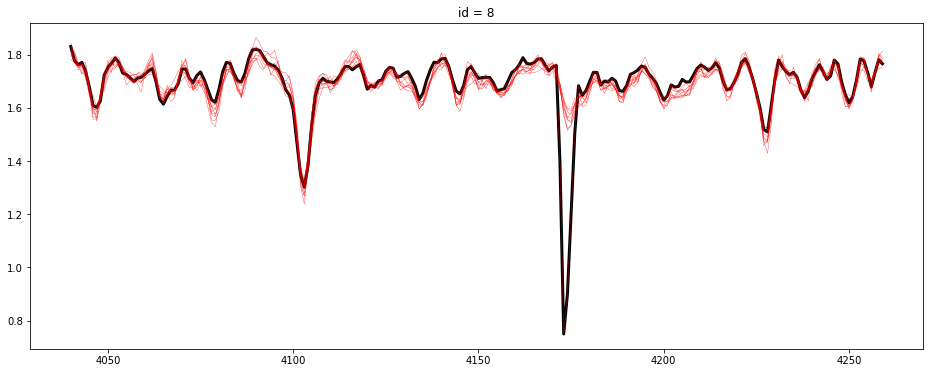

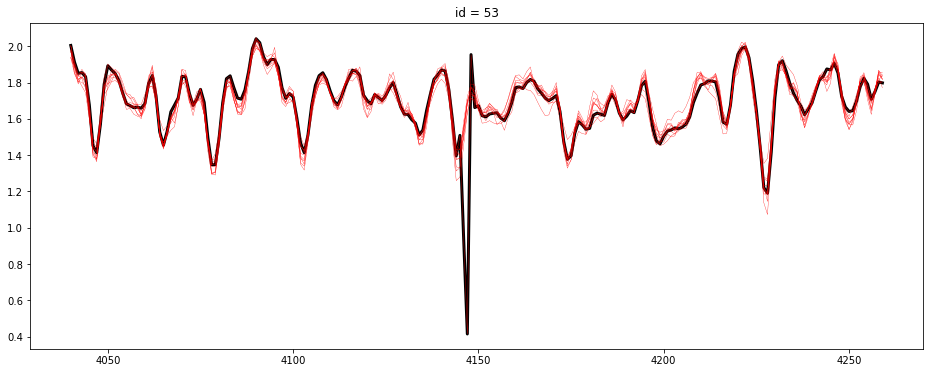

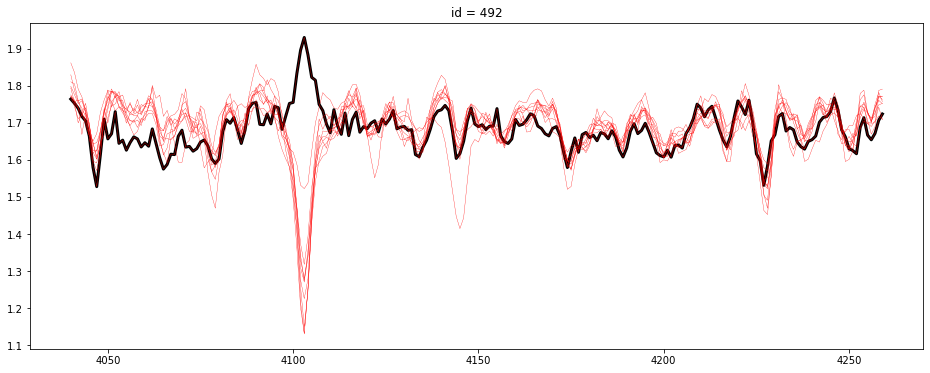

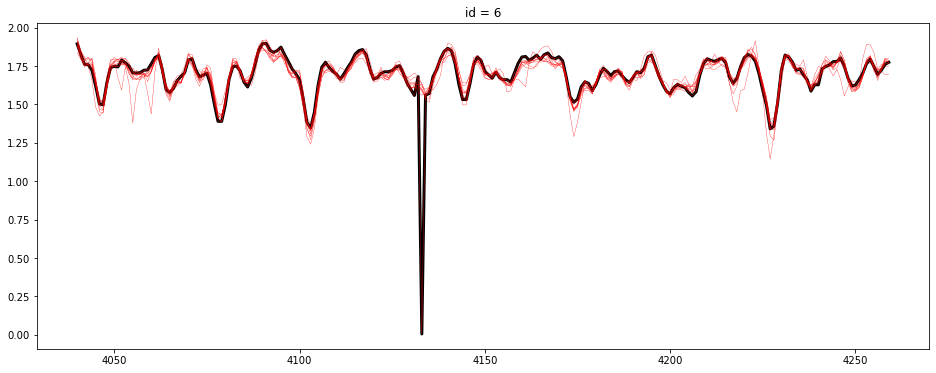

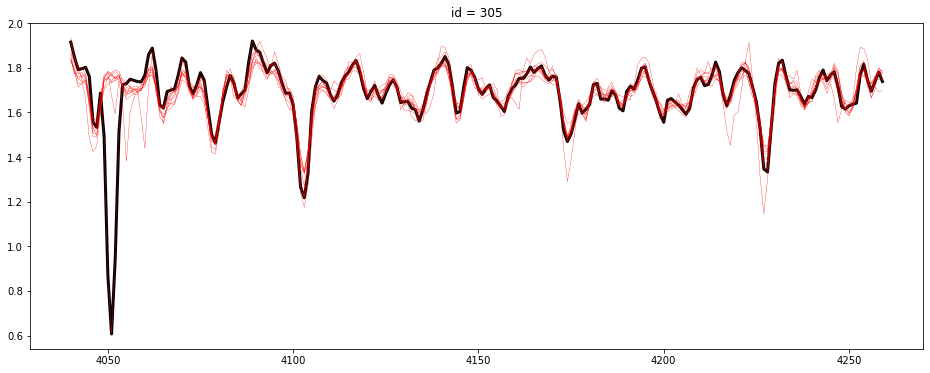

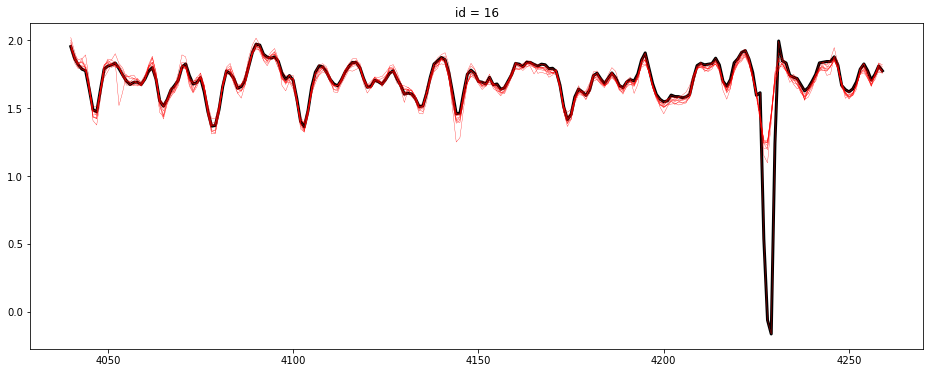

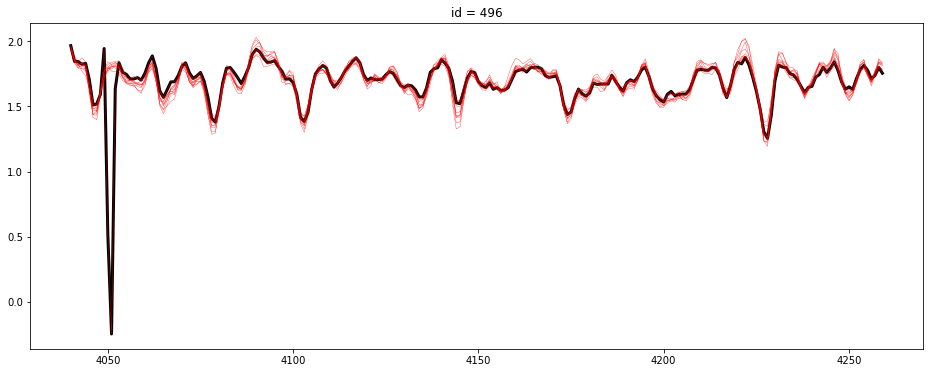

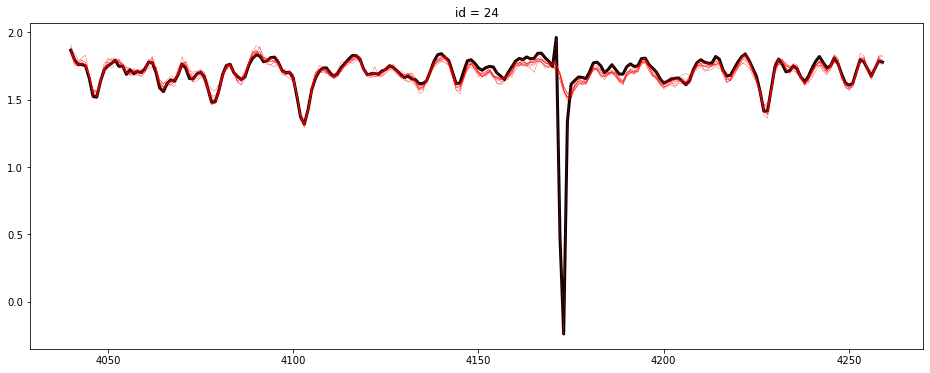

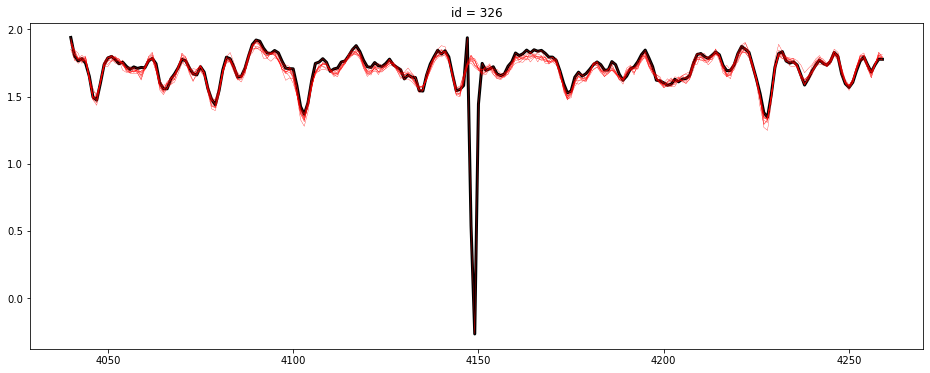

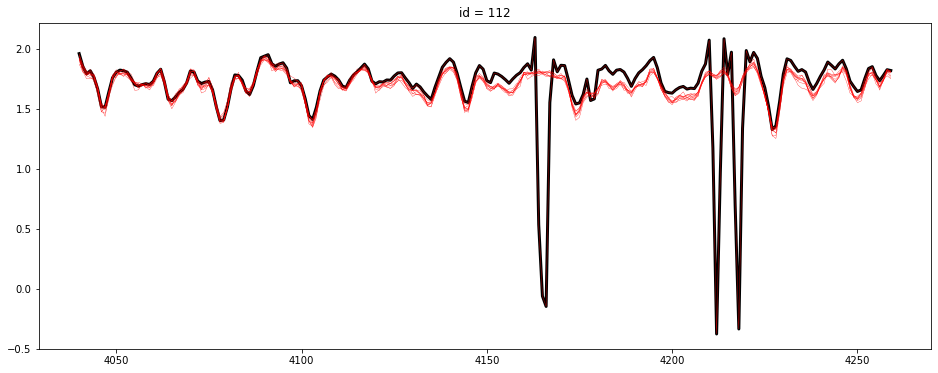

In [72]:
for nowid in ids:
    plot_curve_with_10nbs(nowid)